In [1]:
import os
import warnings

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')
TRAIN_FILE = 'train.csv'


def load_titanic_data(train_file=TRAIN_FILE):
    return pd.read_csv(train_file)

titanic = load_titanic_data()
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
titanic = titanic.set_index('PassengerId')

In [3]:
titanic.shape

(891, 11)

In [4]:
titanic.describe().T

,count,mean,std,min,25%,50%,75%,max
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


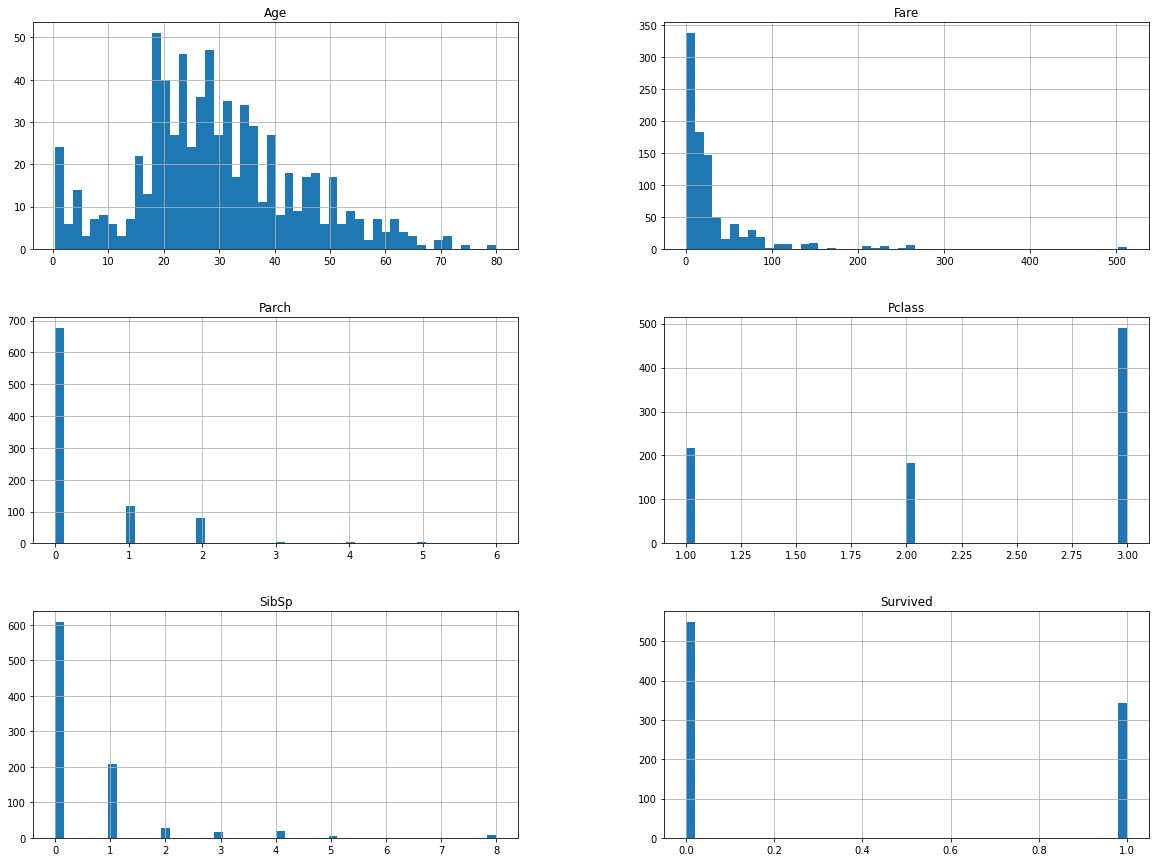

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
titanic.hist(bins=50, figsize=(20,15))
plt.show()

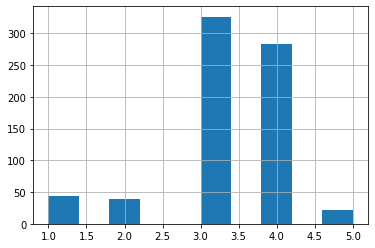

In [6]:
titanic['Age Category'] = pd.cut(titanic['Age'], bins=[0., 5., 15., 30., 60., np.inf], labels=[1,2,3,4,5])
titanic['Age Category'].hist()
plt.show()

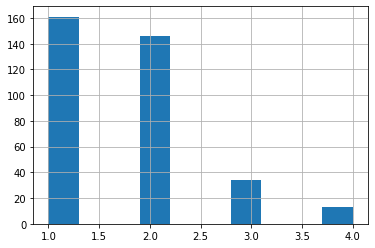

In [299]:
titanic['Family Size'] = titanic['Parch'] + titanic['SibSp']
titanic['Family Category'] = pd.cut(titanic['Family Size'], bins=[0., 1., 4., 6., np.inf], labels=[1,2,3,4])
titanic['Family Category'].hist()
plt.show()

In [300]:
corr_matrix = titanic.corr(method='spearman')
corr_matrix['Survived'].sort_values(ascending=False)

Survived       1.000000
Fare           0.323736
Name Length    0.305809
Family Size    0.165463
Parch          0.138266
SibSp          0.088879
Age           -0.052565
Pclass        -0.339668
Name: Survived, dtype: float64

In [301]:
titanic['Name Length'] = titanic['Name'].fillna('').apply(len)
corr_matrix = titanic.corr(method='spearman')
corr_matrix['Survived'].sort_values(ascending=False)

Survived       1.000000
Fare           0.323736
Name Length    0.305809
Family Size    0.165463
Parch          0.138266
SibSp          0.088879
Age           -0.052565
Pclass        -0.339668
Name: Survived, dtype: float64

In [302]:
titanic.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age Category,Name Length,Family Size,Family Category
PassengerId,,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,MISSING Cabin,S,3,23,1,1
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,4,51,1,1
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,MISSING Cabin,S,3,22,0,NaN
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,4,44,1,1
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,MISSING Cabin,S,4,24,0,NaN


In [306]:
num_cols = ['Age', 'Fare', 'Name Length']
cat_cols = ['Sex', 'Embarked']  # ticket # and cabin is useless!
ord_cols = ['Pclass', 'Family Category']

for col in cat_cols:
    titanic[col] = titanic[col].fillna(titanic[col].mode())

titanic_num = titanic[num_cols]
titanic_cat = titanic[cat_cols]
titanic_ord = titanic[ord_cols]

In [307]:
num_imputer = SimpleImputer(strategy='median')
num_imputer.fit(titanic_num)
X = num_imputer.transform(titanic_num)
titanic_tr = pd.DataFrame(X, columns=titanic_num.columns, index=titanic_num.index)

In [308]:
one_hot = OneHotEncoder()
titanic_cat_encoded = one_hot.fit_transform(titanic_cat)
titanic_cat_encoded.shape

(891, 6)

In [309]:
ordinal_imputer = SimpleImputer(strategy='median')
ordinal_imputer.fit(titanic_ord)
X_ord = ordinal_imputer.fit_transform(titanic_ord)
ordinal_encoder = OrdinalEncoder()
titanic_ord_encoded = ordinal_encoder.fit_transform(X_ord)
titanic_ord.shape

(891, 2)

In [310]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('std_scaler', StandardScaler())
])

ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('ord_encoder', OrdinalEncoder()),
])

In [311]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
for train_index, test_index in split.split(titanic, titanic['Age Category'].fillna(1)):
    train_set = titanic.iloc[train_index]
    test_set = titanic.iloc[test_index]

In [312]:
x_train, y_train = train_set.drop(columns='Survived'), train_set['Survived']
x_test, y_test = test_set.drop(columns='Survived'), test_set['Survived']

In [313]:
from sklearn.compose import ColumnTransformer

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', OneHotEncoder(), cat_cols),
    ('ord', ord_pipeline, ord_cols)
])

x_train_prepared = full_pipeline.fit_transform(x_train)

In [314]:
def evaluate_model(name, model, x, y):
    print(f'Evaluating {name}...')
    scores = cross_val_score(model, x, y)
    mean_score = scores.mean()
    print(f'Average accuracy during cross validation: {mean_score}\n')
    return mean_score
#     model.fit(x, y)
#     predictions = model.predict(x)
#     print(classification_report(y, predictions))

In [315]:
best_model = ''
best_score = float('-inf')
for name, model in [
    ('log_reg', LogisticRegression()),
    ('svc', SVC(C=1)),
    ('decision_tree', DecisionTreeClassifier()),
    ('extra_trees', ExtraTreeClassifier()),
    ('k_neighbors', KNeighborsClassifier(n_neighbors=1)),
    ('grad_boost', GradientBoostingClassifier()),
    ('rand_forest', RandomForestClassifier()),
    ('mlp', MLPClassifier())
]:
    score = evaluate_model(name, model, x_train_prepared, y_train)
    if score > best_score:
        best_score = score
        best_model = name
print("Best model: ", best_model)

Evaluating log_reg...
Average accuracy during cross validation: 0.7785419354838711

Evaluating svc...
Average accuracy during cross validation: 0.8026451612903227

Evaluating decision_tree...
Average accuracy during cross validation: 0.7319612903225806

Evaluating extra_trees...
Average accuracy during cross validation: 0.7351483870967742

Evaluating k_neighbors...
Average accuracy during cross validation: 0.7255741935483871

Evaluating grad_boost...
Average accuracy during cross validation: 0.8090322580645163

Evaluating rand_forest...
Average accuracy during cross validation: 0.778567741935484

Evaluating mlp...


/home/admin/.pyenv/versions/3.8.2/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:582: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/admin/.pyenv/versions/3.8.2/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:582: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/admin/.pyenv/versions/3.8.2/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:582: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/admin/.pyenv/versions/3.8.2/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:582: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.wa

Average accuracy during cross validation: 0.7961548387096775

Best model:  grad_boost


/home/admin/.pyenv/versions/3.8.2/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:582: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [213]:
param_grid = [
    {
        'n_estimators': [1, 10, 100], 
        'max_depth': [None, 2, 4, 16],
        'max_features': [None, 2, 4, 8],
        'max_leaf_nodes': [None, 2, 4, 16],
        'max_samples': [None, 100, 450]
    },
]

rfc = RandomForestClassifier()
grid_search = GridSearchCV(rfc, param_grid, cv=5, 
                           scoring='accuracy', 
                           return_train_score=True, refit=True)
grid_search.fit(x_train_prepared, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid=[{'max_depth': [None, 2, 4, 16],
                          'max_features': [None, 2, 4, 8],
                          'max_leaf_nodes': [None, 2, 4, 16],
                          'max_samples': [None, 100, 450],
                          'n_estimators': [1, 10, 100]}],
             return_train_score=True, scoring='accuracy')

In [214]:
print(grid_search.best_params_)
print(grid_search.best_estimator_)

{'max_depth': 4, 'max_features': 4, 'max_leaf_nodes': 16, 'max_samples': 450, 'n_estimators': 10}
RandomForestClassifier(max_depth=4, max_features=4, max_leaf_nodes=16,
                       max_samples=450, n_estimators=10)


In [215]:
# cv_results = grid_search.cv_results_
# for mean_score, params in zip(cv_results['mean_test_score'], cv_results['params']):
#     print(mean_score, params)

In [216]:
final_model = grid_search.best_estimator_

x_test_prepared = full_pipeline.transform(x_test)
final_predictions = final_model.predict(x_test_prepared)
print(classification_report(y_test, final_predictions))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       167
           1       0.79      0.73      0.76       101

    accuracy                           0.82       268
   macro avg       0.82      0.81      0.81       268
weighted avg       0.82      0.82      0.82       268



In [317]:
test_data = load_titanic_data('test.csv')

In [318]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [319]:
test_data = test_data.set_index('PassengerId')
test_data['Age Category'] = pd.cut(test_data['Age'], bins=[0., 5., 15., 30., 60., np.inf], labels=[1,2,3,4,5])
test_data['Family Size'] = test_data['Parch'] + test_data['SibSp']
test_data['Family Category'] = pd.cut(test_data['Family Size'], bins=[0., 1., 4., 6., np.inf], labels=[1,2,3,4])
test_data['Name Length'] = test_data['Name'].fillna('').apply(len)
test_data = test_data[x_train.columns]

for col in cat_cols:
    test_data[col] = test_data[col].fillna(test_data[col].mode())
    
test_data_prepared = full_pipeline.transform(test_data)

In [320]:
test_predictions = final_model.predict(test_data_prepared)

In [321]:
submission = pd.DataFrame({
    'PassengerId': test_data.index,
    'Survived': test_predictions
})

submission.to_csv('submission.csv', index=False)

In [328]:
!kaggle competitions submit -c titanic -f submission.csv -m "keras last for today"

100%|██████████████████████████████████████| 2.77k/2.77k [00:01<00:00, 2.13kB/s]
Successfully submitted to Titanic: Machine Learning from Disaster

In [322]:
from tensorflow import keras

In [323]:
# scaler = StandardScaler()
# x_train_scaled = scaler.fit_transform(x_train_prepared)
# x_test_scaled = scaler.transform(x_test_prepared)

model = keras.models.Sequential([
    keras.layers.Dense(32, input_shape=(x_train_prepared.shape[1],), activation='elu', kernel_initializer="he_normal"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(20, activation='elu', kernel_initializer="he_normal"),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train_prepared, y_train, epochs=50, 
          validation_data=(x_test_prepared, y_test))

Epoch 1/50
20/20 [==============================] - 0s 8ms/step - loss: 0.8102 - accuracy: 0.5698 - val_loss: 0.6202 - val_accuracy: 0.6455
Epoch 2/50
20/20 [==============================] - 0s 5ms/step - loss: 0.6298 - accuracy: 0.6469 - val_loss: 0.5229 - val_accuracy: 0.7164
Epoch 3/50
20/20 [==============================] - 0s 5ms/step - loss: 0.5655 - accuracy: 0.7111 - val_loss: 0.4849 - val_accuracy: 0.7537
Epoch 4/50
20/20 [==============================] - 0s 4ms/step - loss: 0.5399 - accuracy: 0.7335 - val_loss: 0.4665 - val_accuracy: 0.7873
Epoch 5/50
20/20 [==============================] - 0s 4ms/step - loss: 0.5326 - accuracy: 0.7271 - val_loss: 0.4508 - val_accuracy: 0.7948
Epoch 6/50
20/20 [==============================] - 0s 5ms/step - loss: 0.5274 - accuracy: 0.7624 - val_loss: 0.4416 - val_accuracy: 0.7836
Epoch 7/50
20/20 [==============================] - 0s 5ms/step - loss: 0.5041 - accuracy: 0.7721 - val_loss: 0.4361 - val_accuracy: 0.7836
Epoch 8/50
20/20 [==

In [324]:
model.evaluate(x_test_prepared, y_test)

9/9 [==============================] - 0s 2ms/step - loss: 0.3888 - accuracy: 0.8358


[0.3887926936149597, 0.8358209133148193]

In [325]:
predictions = np.squeeze((model.predict(test_data_prepared) > 0.5).astype("int32"))

# predictions = (predictions > 0.5)

In [326]:
submission = pd.DataFrame({
    'PassengerId': test_data.index,
    'Survived': predictions
})

submission.to_csv('submission.csv', index=False)

In [327]:
submission

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
